In [1]:
!pip install sentence-transformers

In [2]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
sentences = [
    #Cricket
    "The Batsman hit a powerful cover drive for four runs.",
    "The Bowler deliverd a fast yoker that shattered the stumps.",
    "The Cricket team celebrated their victory after their final over.",
    "The Fielders positioned themselves strategically  around the pitch.",

    #Cooking
    "The Chef prepared a rich tomato sauce using fresh herbs.",
    "Baking a cake requires accurate measurements and proper timing.",
    "The recipe includes garlic, olive oil, and roated vegetables.",

    #Cyber Security
    "Experts monitor networks for suspicious activity.",\
    "Strong Passwords and 2 factor authentication improve security.",
    "Hackers exploit software vulnerabilities to gain unauthorised access."
]

In [4]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings =  model.encode(sentences)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

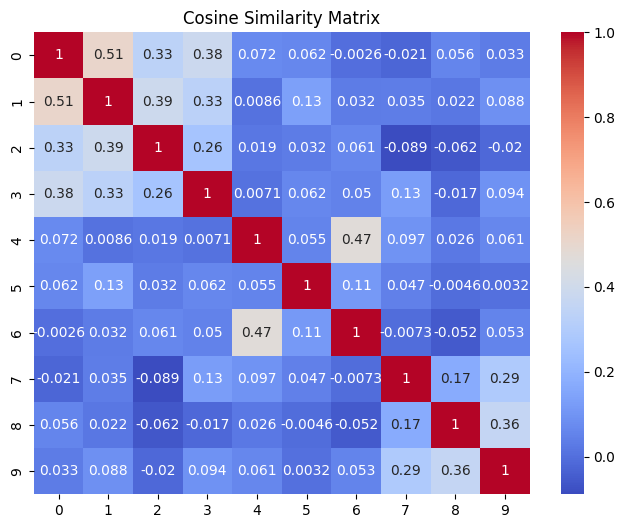

In [5]:
similarity_matrix = cosine_similarity(embeddings)
df=pd.DataFrame(similarity_matrix)
plt.figure(figsize=(8,6))
sns.heatmap(df,annot=True,cmap='coolwarm')
plt.title("Cosine Similarity Matrix")
plt.show()

In [6]:
query = "The bowler took 3 wickets in one over."
query_embedding = model.encode([query])
similarities = cosine_similarity(query_embedding, embeddings)[0]
results = list(zip(sentences,similarities))
results_sorted = sorted(results, key=lambda x: x[1], reverse=True)
top_2 = results_sorted[:2]
print("Top 2 most similar sentences:\n")

for sentence, score in top_2:
  print(sentence)
  print("Similarity Score: ", score)
  print()

Top 2 most similar sentences:

The Bowler deliverd a fast yoker that shattered the stumps.
Similarity Score:  0.62955916

The Batsman hit a powerful cover drive for four runs.
Similarity Score:  0.57043785

